##TASK 2 — UNEMPLOYMENT ANALYSIS WITH PYTHON

##Markdown title

# Unemployment Analysis with Python

### CodeAlpha Data Science Internship — Task 2

**Objective:**  
Analyze unemployment rate data using Python to identify trends,
patterns, regional differences, and the impact of the COVID-19 period.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Project Areas
- Data Cleaning
- Exploratory Data Analysis
- Unemployment Trend Analysis
- Regional Analysis
- COVID-19 Impact Analysis
- Pattern and Seasonal Analysis
- Data Visualization

##Markdown Introduction

## Introduction

Unemployment is an important economic indicator that reflects the
availability of employment opportunities within an economy.

In this project, unemployment data is analyzed using Python and
popular data science libraries. The analysis focuses on understanding
the structure of the dataset, cleaning the available data, exploring
unemployment patterns, visualizing trends over time, comparing
regions, and examining changes during the COVID-19 period.

The findings from this analysis can help identify important
unemployment patterns and provide data-driven insights into
employment conditions.

##Importing Libraries

In [ ]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Set visualization style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


##Uploading Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India.csv


##Loading the Dataset

In [ ]:
# Replace the filename with your actual filename if required

df = pd.read_csv("Unemployment in India.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


First Five Rows

In [ ]:
# Display first five rows

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Last Five Rows

In [ ]:
# Display last five rows

df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dataset Shape

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 7


Column Names

In [ ]:
print("Column Names:\n")

for column in df.columns:
    print(column)

Column Names:

Region
 Date
 Frequency
 Estimated Unemployment Rate (%)
 Estimated Employed
 Estimated Labour Participation Rate (%)
Area


Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


Statistical Summary

In [ ]:
df.describe(include="all")

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
count,740,740,740,740.000000,7.400000e+02,740.000000,740
unique,28,14,2,NaN,NaN,NaN,2
top,Andhra Pradesh,31-10-2019,Monthly,NaN,NaN,NaN,Urban
freq,28,55,381,NaN,NaN,NaN,381
mean,NaN,NaN,NaN,11.787946,7.204460e+06,42.630122,NaN
std,NaN,NaN,NaN,10.721298,8.087988e+06,8.111094,NaN
min,NaN,NaN,NaN,0.000000,4.942000e+04,13.330000,NaN
25%,NaN,NaN,NaN,4.657500,1.190404e+06,38.062500,NaN
50%,NaN,NaN,NaN,8.350000,4.744178e+06,41.160000,NaN
75%,NaN,NaN,NaN,15.887500,1.127549e+07,45.505000,NaN


#Data Cleaning

###Checking Missing Values

In [ ]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


###Missing Value Percenatge

In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table

,Missing Values,Percentage
Region,28,3.645833
Date,28,3.645833
Frequency,28,3.645833
Estimated Unemployment Rate (%),28,3.645833
Estimated Employed,28,3.645833
Estimated Labour Participation Rate (%),28,3.645833
Area,28,3.645833


###Checking Duplicates

In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 27


###Removing Unneccesary Spaces from Column Names

In [ ]:
# Remove leading/trailing spaces from column names

df.columns = df.columns.str.strip()

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


###Cleaning Object Columns

In [ ]:
# Remove unnecessary spaces from text columns

for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


###Converting Date Column

In [ ]:
# Convert Date column into datetime format

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print(df["Date"].dtype)

datetime64[ns]


###Checking Date Conversion

In [ ]:
print("Minimum Date:", df["Date"].min())
print("Maximum Date:", df["Date"].max())

Minimum Date: 2019-05-31 00:00:00
Maximum Date: 2020-06-30 00:00:00


###Checking Numeric Columns

In [ ]:
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print(df[numeric_columns].dtypes)

Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
dtype: object


###Check Cleaing Results

In [ ]:
print("Missing values after cleaning:\n")
print(df.isnull().sum())

Missing values after cleaning:

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


###Removing Missing Rows

In [ ]:
# Remove rows with missing values

df_clean = df.dropna().copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape :", df_clean.shape)

Original dataset shape: (768, 7)
Cleaned dataset shape : (740, 7)


#Exploratory Data Analysis

###Cleaning Dataset Preview

In [ ]:
df_clean.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


###Descriptive Statistcs

In [ ]:
df_clean[numeric_columns].describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


###Average of Unemployement Rate

In [ ]:
average_unemployment = (
    df_clean["Estimated Unemployment Rate (%)"].mean()
)

print(
    f"Average Unemployment Rate: "
    f"{average_unemployment:.2f}%"
)

Average Unemployment Rate: 11.79%


###Median of Unemployement Rate

In [ ]:
median_unemployment = (
    df_clean["Estimated Unemployment Rate (%)"].median()
)

print(
    f"Median Unemployment Rate: "
    f"{median_unemployment:.2f}%"
)

Median Unemployment Rate: 8.35%


###Minimum and Maximum

In [ ]:
unemployment = df_clean[
    "Estimated Unemployment Rate (%)"
]

print(f"Minimum Unemployment Rate: {unemployment.min():.2f}%")
print(f"Maximum Unemployment Rate: {unemployment.max():.2f}%")

Minimum Unemployment Rate: 0.00%
Maximum Unemployment Rate: 76.74%


#UNEMPLOYEMENT DISTRIBUTION

###Histogram

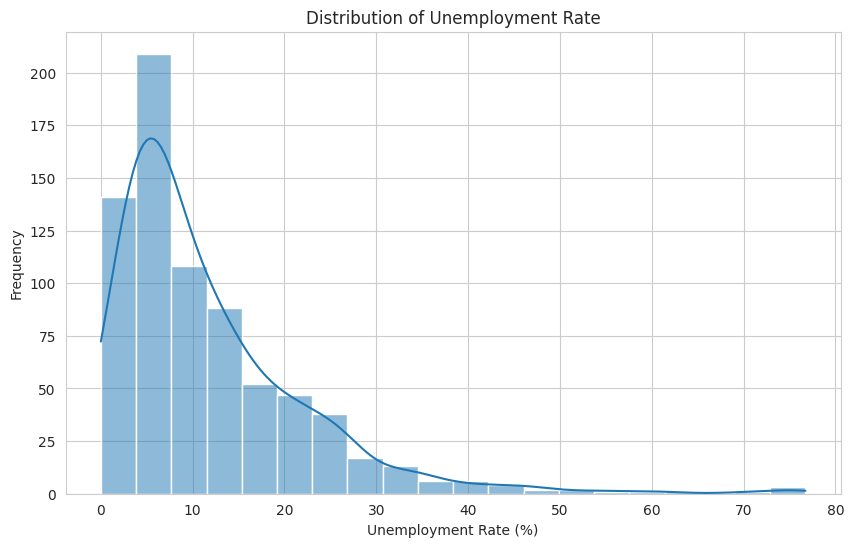

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_clean["Estimated Unemployment Rate (%)"],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")

plt.show()

###Box Plot

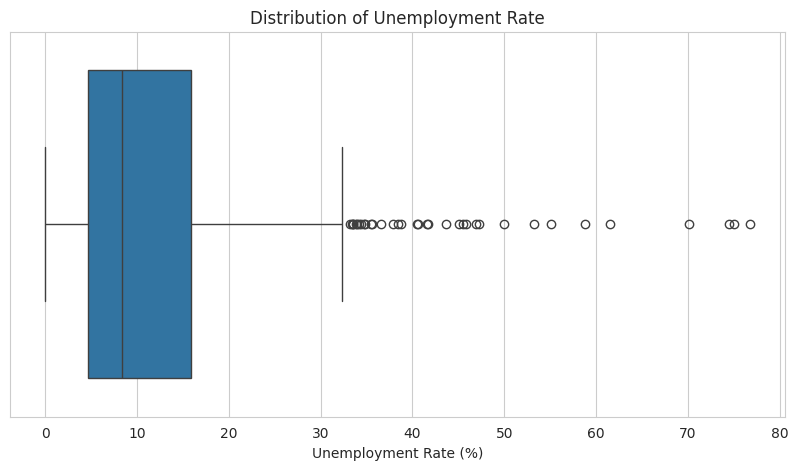

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df_clean["Estimated Unemployment Rate (%)"]
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")

plt.show()

#REGIONAL ANALYSIS

###Average Unemployment by Region

In [ ]:
region_unemployment = (
    df_clean
    .groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_unemployment

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


###Regional Bar Chart

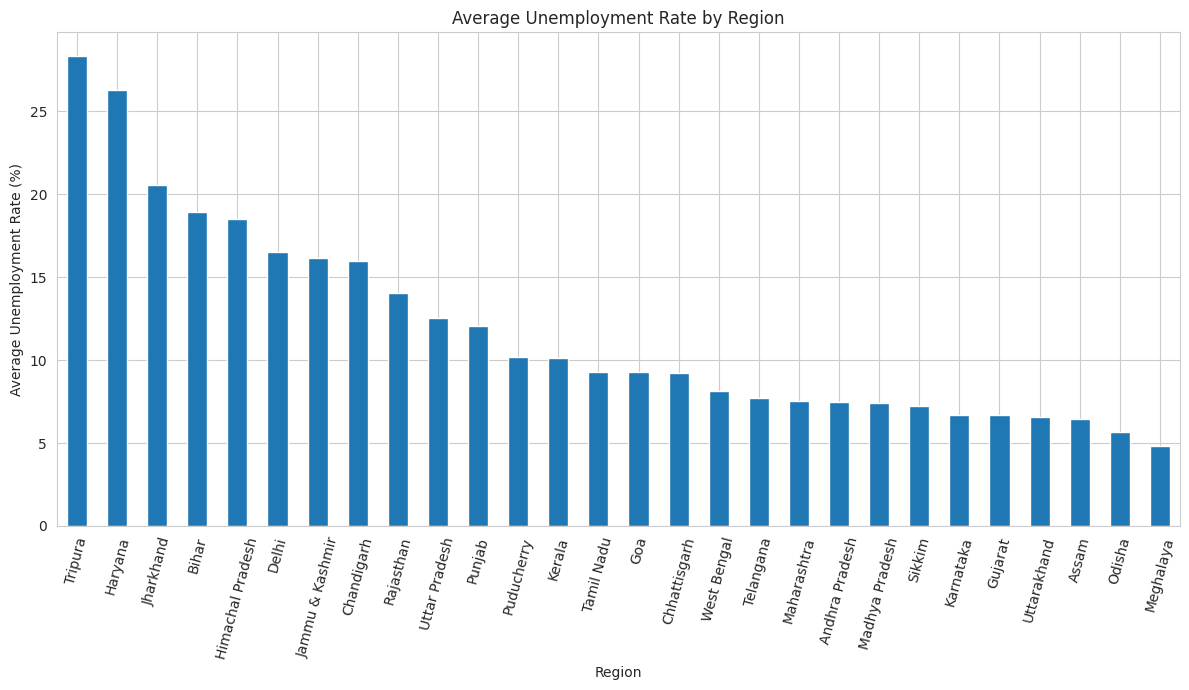

In [ ]:
plt.figure(figsize=(12, 7))

region_unemployment.plot(
    kind="bar"
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

###Top Regions

In [ ]:
print("Top 10 regions with highest average unemployment:")

print(
    region_unemployment
    .head(10)
)

Top 10 regions with highest average unemployment:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


###Lowest Regions

In [ ]:
print("10 regions with lowest average unemployment:")

print(
    region_unemployment
    .tail(10)
)

10 regions with lowest average unemployment:
Region
Maharashtra       7.557500
Andhra Pradesh    7.477143
Madhya Pradesh    7.406429
Sikkim            7.249412
Karnataka         6.676071
Gujarat           6.663929
Uttarakhand       6.582963
Assam             6.428077
Odisha            5.657857
Meghalaya         4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


#TIME BASED ANALYSIS

###Monthly Average Unemployment

In [ ]:
monthly_unemployment = (
    df_clean
    .groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_index()
)

monthly_unemployment.head()

,Estimated Unemployment Rate (%)
Date,
2019-05-31,8.874259
2019-06-30,9.303333
2019-07-31,9.033889
2019-08-31,9.637925
2019-09-30,9.051731


###Unemployment Trend

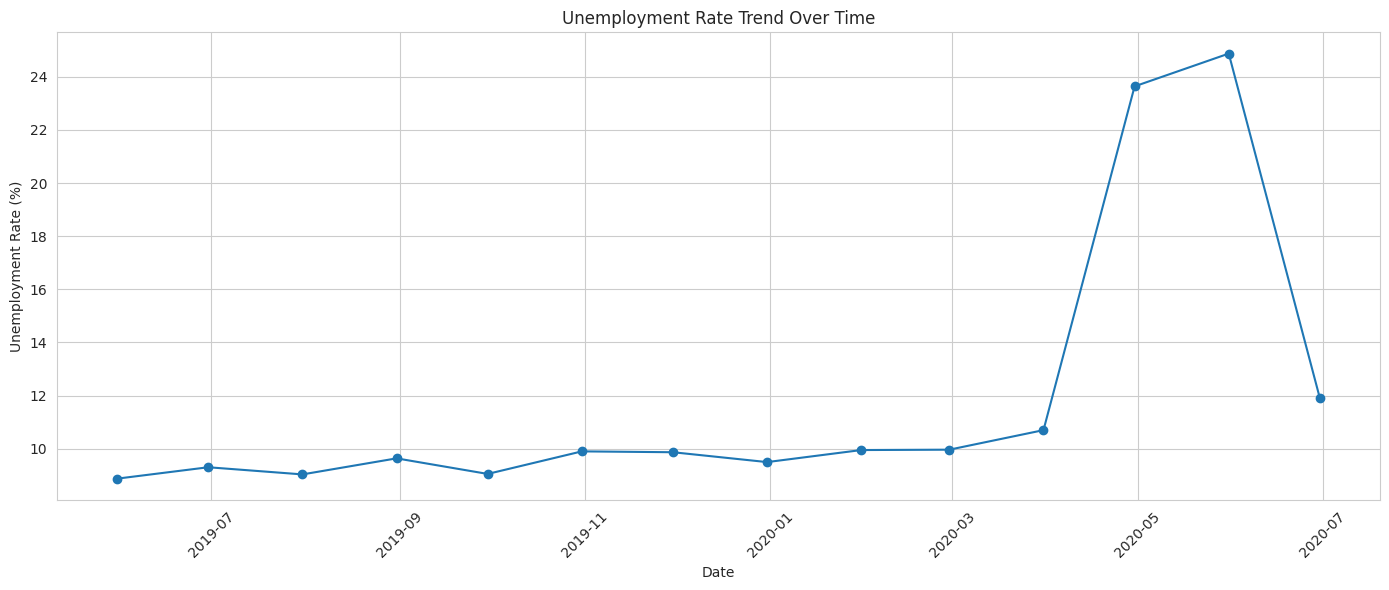

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker="o"
)

plt.title("Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#COVID-19 IMPACT ANALYSIS

###Creating COVID Period

In [ ]:
# Create a period classification

df_clean["Period"] = np.where(
    df_clean["Date"] < pd.Timestamp("2020-03-01"),
    "Pre-COVID",
    "COVID Period"
)

df_clean[["Date", "Period"]].head()

,Date,Period
0,2019-05-31,Pre-COVID
1,2019-06-30,Pre-COVID
2,2019-07-31,Pre-COVID
3,2019-08-31,Pre-COVID
4,2019-09-30,Pre-COVID


###Comparing Periods

In [ ]:
covid_comparison = (
    df_clean
    .groupby("Period")["Estimated Unemployment Rate (%)"]
    .agg(["mean", "median", "min", "max"])
)

covid_comparison

,mean,median,min,max
Period,,,,
COVID Period,17.774363,14.520,0.0,76.74
Pre-COVID,9.509534,7.115,0.0,34.69


###COVID Comparision Chart

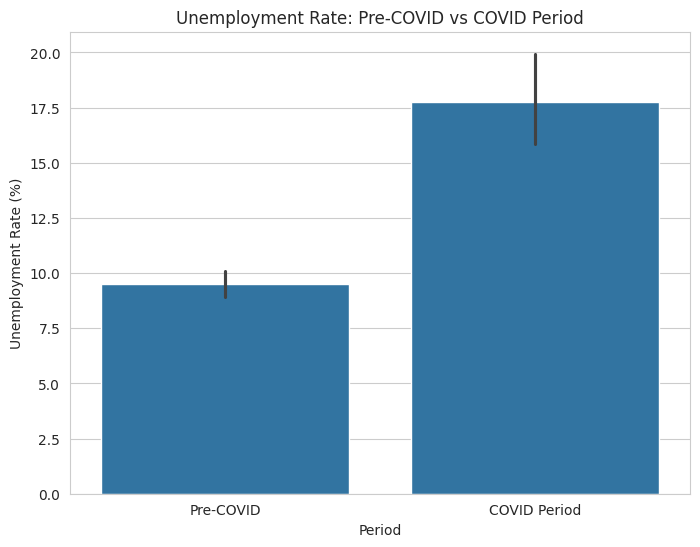

In [ ]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_clean,
    x="Period",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Unemployment Rate: Pre-COVID vs COVID Period")
plt.xlabel("Period")
plt.ylabel("Unemployment Rate (%)")

plt.show()

###Calculating Change

In [ ]:
pre_covid_rate = df_clean.loc[
    df_clean["Period"] == "Pre-COVID",
    "Estimated Unemployment Rate (%)"
].mean()

covid_rate = df_clean.loc[
    df_clean["Period"] == "COVID Period",
    "Estimated Unemployment Rate (%)"
].mean()

change = covid_rate - pre_covid_rate

percentage_change = (
    change / pre_covid_rate
) * 100

print(f"Pre-COVID Average: {pre_covid_rate:.2f}%")
print(f"COVID Period Average: {covid_rate:.2f}%")
print(f"Absolute Change: {change:.2f} percentage points")
print(f"Percentage Change: {percentage_change:.2f}%")

Pre-COVID Average: 9.51%
COVID Period Average: 17.77%
Absolute Change: 8.26 percentage points
Percentage Change: 86.91%


#SEASONAL ANALYSIS

###Extract Month

In [ ]:
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Month_Name"] = df_clean["Date"].dt.month_name()

df_clean[["Date", "Month", "Month_Name"]].head()

,Date,Month,Month_Name
0,2019-05-31,5,May
1,2019-06-30,6,June
2,2019-07-31,7,July
3,2019-08-31,8,August
4,2019-09-30,9,September


###Monthly Average

In [ ]:
monthly_pattern = (
    df_clean
    .groupby(["Month", "Month_Name"])
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
    .sort_values("Month")
)

monthly_pattern

,Month,Month_Name,Estimated Unemployment Rate (%)
0,1,January,9.950755
1,2,February,9.964717
2,3,March,10.700577
3,4,April,23.641569
4,5,May,16.646190
5,6,June,10.553462
6,7,July,9.033889
7,8,August,9.637925
8,9,September,9.051731
9,10,October,9.900909


###Seasonal Trend Chart

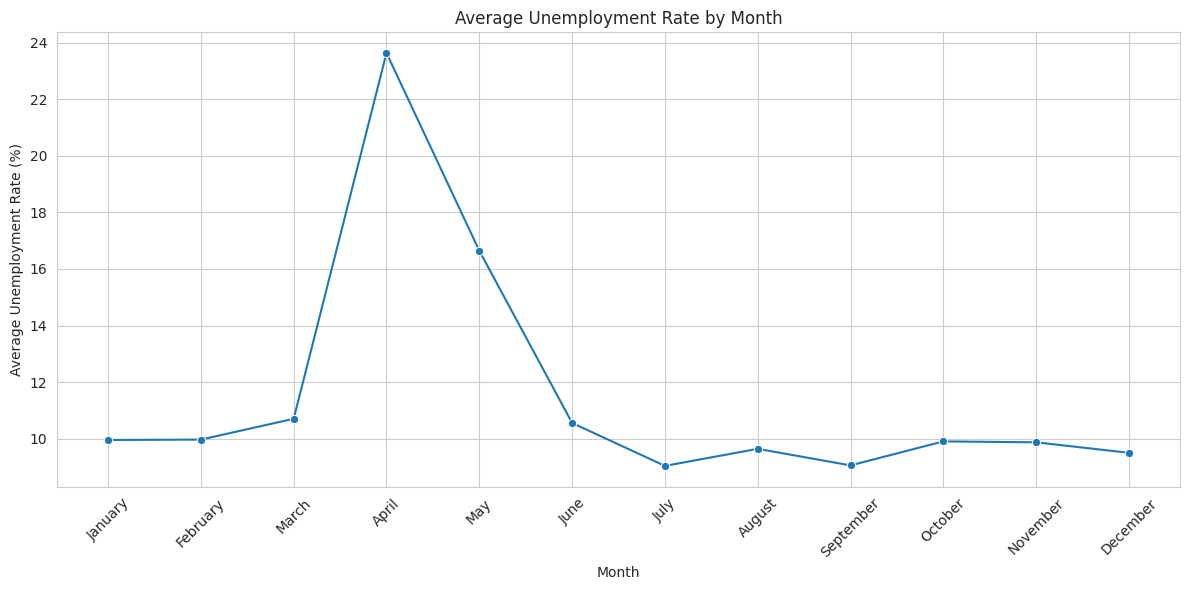

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_pattern,
    x="Month_Name",
    y="Estimated Unemployment Rate (%)",
    marker="o"
)

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#EMPLOYMENT ANALYSIS

###Estimated Employment Trend

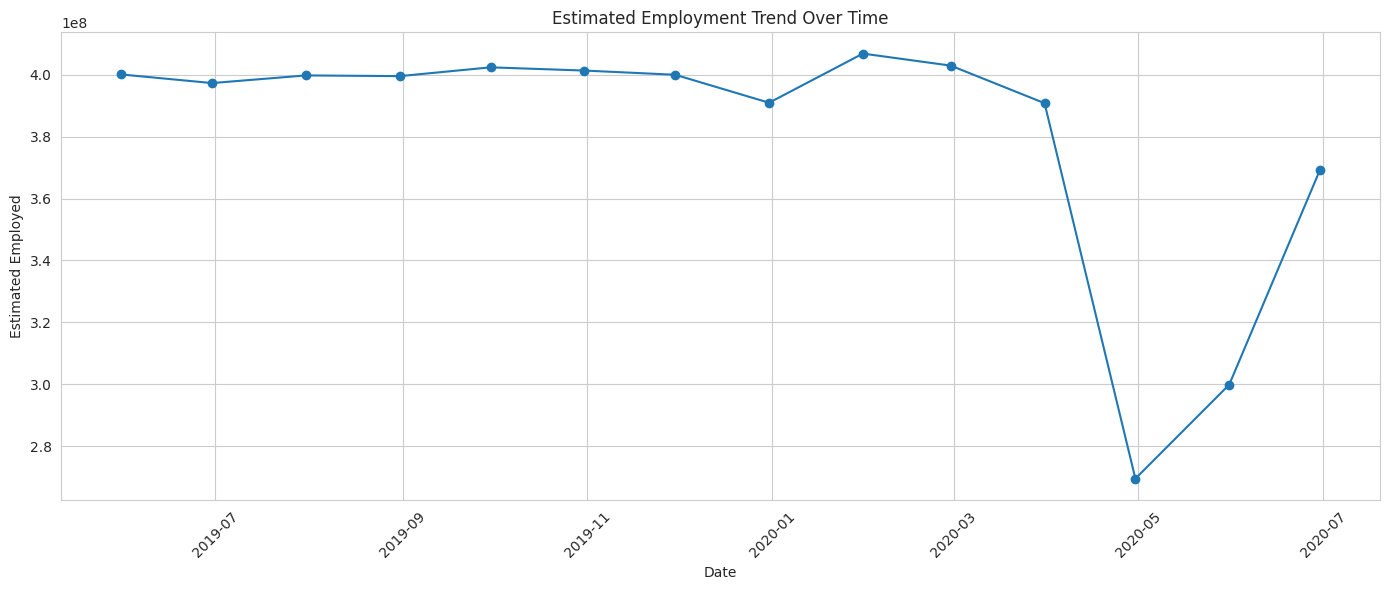

In [ ]:
employment_trend = (
    df_clean
    .groupby("Date")["Estimated Employed"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    employment_trend.index,
    employment_trend.values,
    marker="o"
)

plt.title("Estimated Employment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Employed")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#LABOUR PARTICIPATION ANALYSIS

###Labour Participation Trend

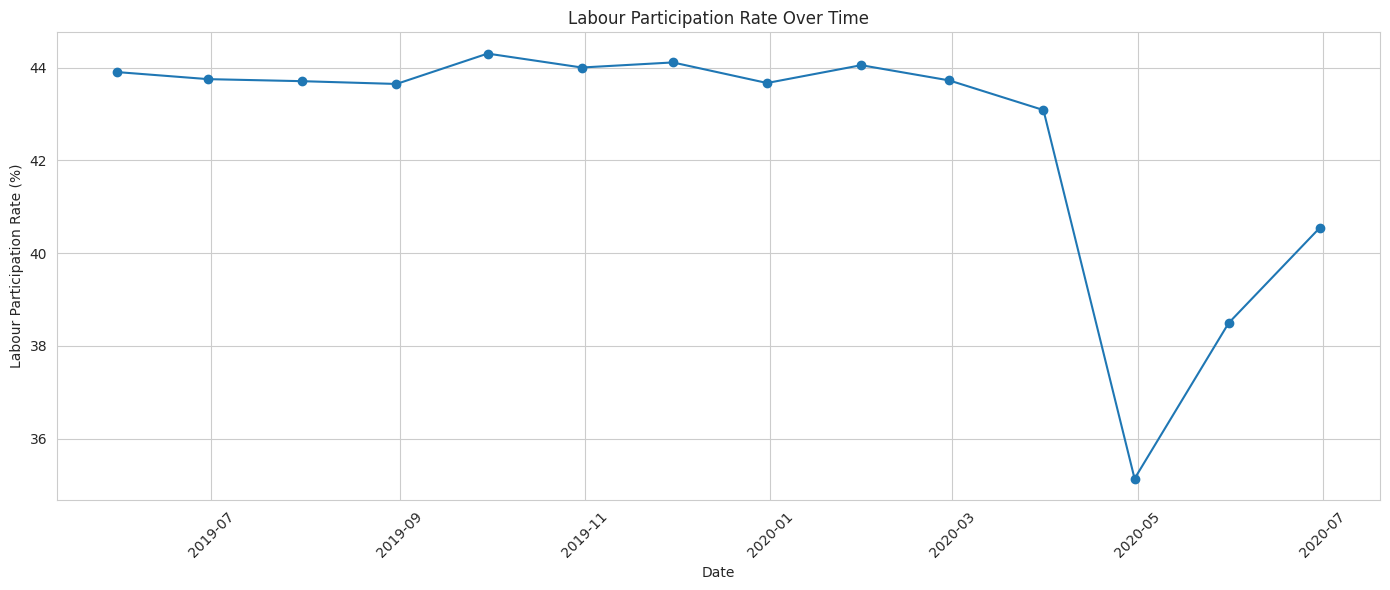

In [ ]:
labour_trend = (
    df_clean
    .groupby("Date")
    ["Estimated Labour Participation Rate (%)"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    labour_trend.index,
    labour_trend.values,
    marker="o"
)

plt.title("Labour Participation Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Labour Participation Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#CORRELATION ANALYSIS

###Correlation Matrix

In [ ]:
correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation_matrix = df_clean[
    correlation_columns
].corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


###Correlation Heatmap

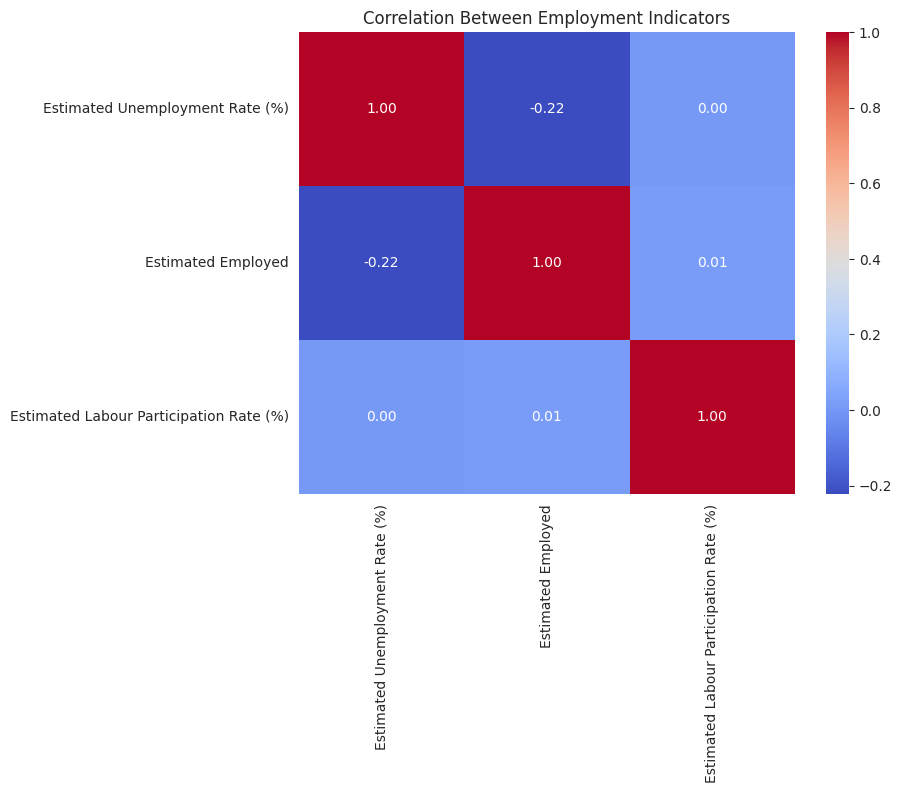

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Employment Indicators")

plt.show()

##Highest Unemployment Observation

In [ ]:
highest_unemployment = df_clean.loc[
    df_clean["Estimated Unemployment Rate (%)"].idxmax()
]

highest_unemployment

,627
Region,Puducherry
Date,2020-04-30 00:00:00
Frequency,Monthly
Estimated Unemployment Rate (%),76.74
Estimated Employed,68122.0
Estimated Labour Participation Rate (%),35.54
Area,Urban
Period,COVID Period
Month,4
Month_Name,April


##Lowest Unemployment Observation

In [ ]:
lowest_unemployment = df_clean.loc[
    df_clean["Estimated Unemployment Rate (%)"].idxmin()
]

lowest_unemployment

,25
Region,Assam
Date,2020-06-30 00:00:00
Frequency,Monthly
Estimated Unemployment Rate (%),0.0
Estimated Employed,7544937.0
Estimated Labour Participation Rate (%),34.38
Area,Rural
Period,COVID Period
Month,6
Month_Name,June


##Key Insights

In [ ]:
print("========== KEY INSIGHTS ==========\n")

print(
    f"Average unemployment rate: "
    f"{df_clean['Estimated Unemployment Rate (%)'].mean():.2f}%"
)

print(
    f"Highest unemployment rate: "
    f"{df_clean['Estimated Unemployment Rate (%)'].max():.2f}%"
)

print(
    f"Lowest unemployment rate: "
    f"{df_clean['Estimated Unemployment Rate (%)'].min():.2f}%"
)

print(
    f"Highest average-unemployment region: "
    f"{region_unemployment.index[0]}"
)

print(
    f"Lowest average-unemployment region: "
    f"{region_unemployment.index[-1]}"
)

print(
    f"Pre-COVID average: "
    f"{pre_covid_rate:.2f}%"
)

print(
    f"COVID-period average: "
    f"{covid_rate:.2f}%"
)

print("\n==================================")

========== KEY INSIGHTS ==========

Average unemployment rate: 11.79%
Highest unemployment rate: 76.74%
Lowest unemployment rate: 0.00%
Highest average-unemployment region: Tripura
Lowest average-unemployment region: Meghalaya
Pre-COVID average: 9.51%
COVID-period average: 17.77%



# Conclusion

This project analyzed unemployment data using Python and data analysis
techniques. The dataset was cleaned and explored to understand its
structure, statistical characteristics, regional variations, and
changes over time.

Visualizations were created to identify unemployment trends and
patterns. Regional analysis helped compare unemployment levels across
different regions, while the COVID-19 analysis provided a comparison
between the pre-COVID and COVID periods.

Monthly analysis was also performed to investigate possible seasonal
patterns in unemployment.

### Key Takeaways

- The unemployment dataset was successfully cleaned and analyzed.
- Statistical analysis was used to understand unemployment levels.
- Time-series visualizations revealed changes in unemployment over time.
- Regional analysis highlighted differences in unemployment rates.
- The COVID-19 period was compared with the pre-COVID period.
- Monthly patterns were investigated for possible seasonal trends.
- Employment and labour participation indicators were also examined.
- The analysis provides data-driven insights into unemployment conditions.

Overall, this project demonstrates how Python, Pandas, Matplotlib,
and Seaborn can be used to transform unemployment data into
meaningful analytical insights.